** Business Challenge 1: Application of Customer Sentiment Analysis on Yelp Dataset **
Yelp is an online platform where people can rate, review, and share experiences about local
businesses. Customer reviews contain valuable insights into customer satisfaction, product
quality, and service delivery. However, the massive volume makes it impossible for
managers to manually read and interpret all reviews. The company is therefore exploring
automated sentiment analysis to understand customer opinions at scale and make datadriven decisions that improve service quality and competitiveness.

In [1]:
#%pip install datasets
#%pip install transformers torch
from datasets import load_dataset
dataset = load_dataset("yelp_polarity")
print(dataset)
# 'dataset' is a DatasetDict (not callable). Access splits like this:
print(dataset['train'][0])

c:\Users\fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})
{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.", 'label': 0}


In [2]:
# Imports ( add more if needed )
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import torch
import os
import json

Task I: Understanding Customer Feedback (Exploratory Analysis)
Before building models, the analytics team must understand the structure of customer
feedback:
1. Assess whether there is a class imbalance (e.g., more positive reviews than
negative).
2. Extract and display sample reviews from both positive and negative categories to
illustrate customer voice.
3. Plot the distribution of review lengths to evaluate typical review detail and prepare
for model design.

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})
--- Class Distribution in Training Set ---
label
0    280000
1    280000
Name: count, dtype: int64

Percentage of Negative (0) reviews: 50.00%
Percentage of Positive (1) reviews: 50.00%


C:\Users\fabio\AppData\Local\Temp\ipykernel_22628\2784106740.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette=["red", "green"])


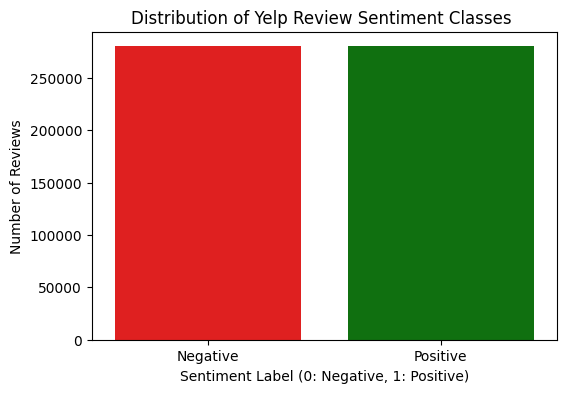

In [3]:
# load dataset and preprocess
print(dataset)
train_df = pd.DataFrame(dataset['train'])
#1.1 - Distribution of classes in training set.
# Calculate value counts for the 'label' column
label_counts = train_df['label'].value_counts()

print("--- Class Distribution in Training Set ---")
print(label_counts)

# Calculate percentages
total_samples = len(train_df)
percent_0 = (label_counts[0] / total_samples) * 100
percent_1 = (label_counts[1] / total_samples) * 100

print(f"\nPercentage of Negative (0) reviews: {percent_0:.2f}%")
print(f"Percentage of Positive (1) reviews: {percent_1:.2f}%")

# Visualization of Class Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette=["red", "green"])
plt.title('Distribution of Yelp Review Sentiment Classes ')
plt.xlabel('Sentiment Label (0: Negative, 1: Positive)')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [4]:
#1.2 - Extract and display sample reviews from both positive and negative categories to illustrate customer voice
# Get sample negative reviews (Label 0)
negative_samples = train_df[train_df['label'] == 0]['text'].head(3)

# Get sample positive reviews (Label 1)
positive_samples = train_df[train_df['label'] == 1]['text'].head(3)

print("--- Sample Negative Reviews (Label 0) ---")
for i, review in enumerate(negative_samples):
    print(f"Review {i+1}:\n{review}\n---")

print("\n--- Sample Positive Reviews (Label 1) ---")
for i, review in enumerate(positive_samples):
    print(f"Review {i+1}:\n{review}\n---")

--- Sample Negative Reviews (Label 0) ---
Review 1:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.
---
Review 2:
I don't know what Dr. Goldberg was like before  moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over when Johnson left. He is not a caring doctor. He is only interested in the co-pay and having 

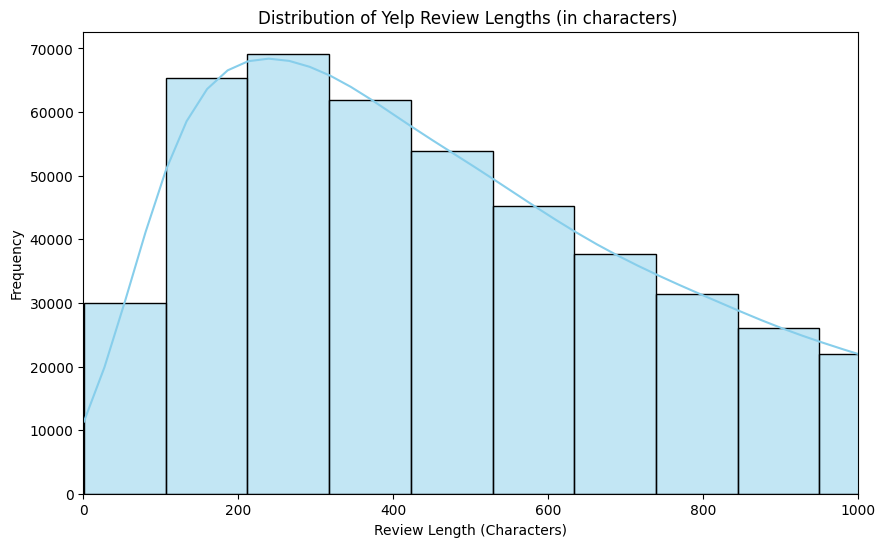


--- Descriptive Statistics for Review Lengths ---
count    560000.000000
mean        726.497923
std         669.844273
min           1.000000
25%         279.000000
50%         528.000000
75%         947.000000
max        5273.000000
Name: review_length, dtype: float64


In [5]:
#1.3 plot the distribution of review lengths for both positive and negative reviews.

# Create a new column for review length
train_df['review_length'] = train_df['text'].apply(len)

# Plot the distribution of review lengths
plt.figure(figsize=(10, 6))
sns.histplot(train_df['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Yelp Review Lengths (in characters) ')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Frequency')
plt.xlim(0, 1000) # Limit x-axis for better visibility of the bulk of the data
plt.show()

# Calculate descriptive statistics for review lengths
print("\n--- Descriptive Statistics for Review Lengths ---")
print(train_df['review_length'].describe())

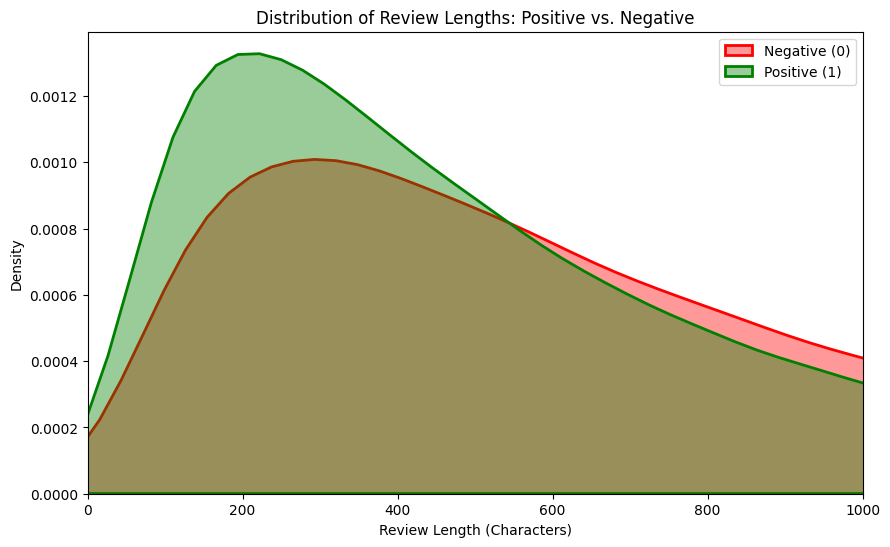

In [6]:
# Comparison Plot of Review Lengths by Sentiment
# --- Code for the Comparison Plot ---
plt.figure(figsize=(10, 6))

# Plot the distribution for Negative Reviews (Label 0)
sns.kdeplot(
    train_df[train_df['label'] == 0]['review_length'],
    label='Negative (0)',
    color='red',
    fill=True,
    alpha=0.4,
    linewidth=2
)

# Plot the distribution for Positive Reviews (Label 1)
sns.kdeplot(
    train_df[train_df['label'] == 1]['review_length'],
    label='Positive (1)',
    color='green',
    fill=True,
    alpha=0.4,
    linewidth=2
)

plt.title('Distribution of Review Lengths: Positive vs. Negative')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Density')
# Based on your statistics (75% is 947), limiting to 1000 is still appropriate
plt.xlim(0, 1000) 
plt.legend()
plt.show() # Crucial command to display the plot

TASK 2 - The company wants an initial benchmark model to classify reviews as positive or
negative.
1. Develop a baseline sentiment classifier using TF-IDF + Random Forest.
2. Provide a validation report on a validation partition of the training set showing
precision, recall, F1-score, and support to assess strengths and weaknesses of the
baseline model.
3. Display a confusion matrix on the validation data to illustrate misclassifications.
4. Use grid search optimization to improve the baseline by tuning:
o Number of estimators [100, 500]
o Maximum tree depth [None, 20, 50]
o Minimum samples split [2, 5]
o Minimum samples per leaf [2, 4]
o Maximum features at each node ["sqrt", "log2"]
5. Report the best model parameters and explain why they are important for business
decision-making.

In [7]:
#2.1 - Develop a Baseline Sentiment Classifier (TF-IDF + Random Forest)
# Use a smaller subset of the training data for faster processing
# Using 50,000 samples for train/validation split
SUBSET_SIZE = 5000 #50000
subset_df = train_df.head(SUBSET_SIZE)

X = subset_df['text']
y = subset_df['label']

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

# 1. TF-IDF Vectorization
# Use up to 10,000 most frequent words/n-grams
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

# 2. Random Forest Classifier (Baseline)
# Use default parameters for the baseline
rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
rf_baseline.fit(X_train_tfidf, y_train)

# Predict on the validation set
y_pred_baseline = rf_baseline.predict(X_val_tfidf)

Training set size: 4000
Validation set size: 1000



--- Baseline Model Validation Report (TF-IDF + Random Forest) ---
              precision    recall  f1-score   support

Negative (0)       0.81      0.88      0.84       522
Positive (1)       0.85      0.78      0.81       478

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



<Figure size 600x600 with 0 Axes>

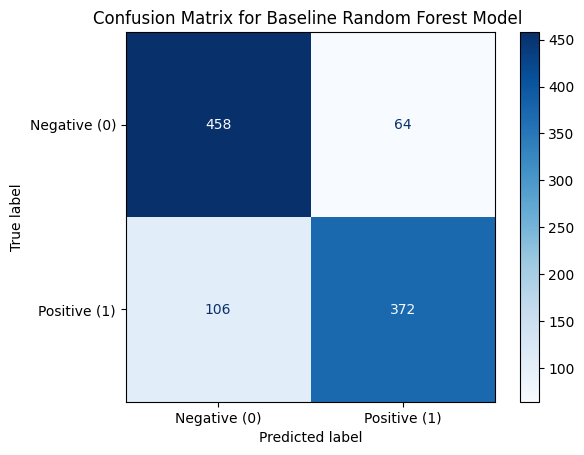

In [8]:
# Baseline Model Validation Report (TF-IDF + Random Forest)
print("\n--- Baseline Model Validation Report (TF-IDF + Random Forest) ---")
print(classification_report(y_val, y_pred_baseline, target_names=['Negative (0)', 'Positive (1)']))

# Display Confusion Matrix
cm = confusion_matrix(y_val, y_pred_baseline)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Baseline Random Forest Model ')
plt.show()

In [9]:
# Optimizing the model using Grid Search CV
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [10, 50], #[100, 500],
    'max_depth': [None, 20, 50],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
    'max_features': ["sqrt", "log2"]
}

# Initialize Grid Search with a smaller, more optimized search space
# Using a subset of the training data (X_train_tfidf, y_train)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1), # n_jobs=-1 for parallel processing
    param_grid=param_grid,
    scoring='f1', # Optimize for F1-score
    cv=3,        # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

# Fit the grid search (This can take several minutes)
print("\n--- Starting Grid Search Optimization (This may take time) ---")
grid_search.fit(X_train_tfidf, y_train)

# Get the best parameters and the corresponding score
best_params = grid_search.best_params_
best_score = grid_search.best_score_


--- Starting Grid Search Optimization (This may take time) ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits


In [10]:
print(f"\n--- Best Random Forest Hyperparameters (Grid Search) ---")
print(best_params)
print(f"Best Cross-Validation F1 Score: {best_score:.4f}")

# Train the best model and evaluate on the validation set
rf_optimized = grid_search.best_estimator_
y_pred_optimized = rf_optimized.predict(X_val_tfidf)

print("\n--- Optimized Model Validation Report ---")
print(classification_report(y_val, y_pred_optimized, target_names=['Negative (0)', 'Positive (1)']))


--- Best Random Forest Hyperparameters (Grid Search) ---
{'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation F1 Score: 0.8076

--- Optimized Model Validation Report ---
              precision    recall  f1-score   support

Negative (0)       0.81      0.86      0.83       522
Positive (1)       0.83      0.77      0.80       478

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



<Figure size 700x700 with 0 Axes>

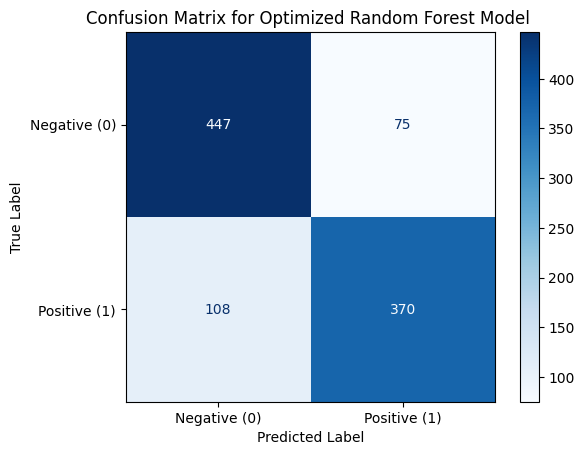


--- Optimized Random Forest Model Validation Report ---
              precision    recall  f1-score   support

Negative (0)       0.81      0.86      0.83       522
Positive (1)       0.83      0.77      0.80       478

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



In [11]:
# Display Confusion Matrix for Optimized Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get the best performing model from Grid Search
rf_optimized = grid_search.best_estimator_

# 2. Predict on the validation set using the optimized model
# X_val_tfidf is the validation data transformed by the TF-IDF vectorizer
y_pred_optimized = rf_optimized.predict(X_val_tfidf)

# 3. Calculate the Confusion Matrix
# y_val is the true sentiment labels for the validation set
cm_optimized = confusion_matrix(y_val, y_pred_optimized)

# 4. Display the Confusion Matrix
plt.figure(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=['Negative (0)', 'Positive (1)']
)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Optimized Random Forest Model ')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Print the Classification Report for a detailed view
print("\n--- Optimized Random Forest Model Validation Report ---")
print(classification_report(y_val, y_pred_optimized, target_names=['Negative (0)', 'Positive (1)']))

Task III: Advanced Sentiment Intelligence with Pretrained Models
The company’s leadership is interested in how cutting-edge AI could outperform the
baseline.
1. Implement two transformer-based pretrained models (from Hugging Face) for
sentiment classification and discuss why you selected each model.
2. Compare their performance against each other and against the optimized Random
Forest model.
3. Quantify how much better the transformer models are and explain the business
impact (e.g., fewer false negatives could prevent overlooking unhappy customers,
better precision could reduce escalation costs).

Model	Justification
1. bert-base-uncased (Base Model)	Industry Standard Baseline: BERT is the foundational transformer model. It's a great choice for a first advanced benchmark, as its architecture is well-understood, and it provides a strong performance baseline before moving to larger or more specialized models.
2. roberta-base (Improved Model)	Performance Leader: RoBERTa (Robustly Optimized BERT Pretraining Approach) is an optimized version of BERT. It was trained longer, on more data, and with different pre-training objectives (dynamic masking), often leading to better performance on downstream tasks like sentiment classification. This showcases the benefit of using state-of-the-art techniques.

In [12]:
#!pip install -U transformers==4.35.2 torch accelerate
#!pip install -U "transformers" "huggingface_hub"
import transformers, huggingface_hub
print("transformers version:", transformers.__version__)
print("huggingface_hub version:", huggingface_hub.__version__)



transformers version: 4.57.2
huggingface_hub version: 0.36.0


In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Define the Model Checkpoints (from Hugging Face Hub)
ROBERTA_MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
DISTILBERT_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

# 1. Load RoBERTa (High Performance Model)
print(f"Loading RoBERTa: {ROBERTA_MODEL}...")
tokenizer_roberta = AutoTokenizer.from_pretrained(ROBERTA_MODEL)
model_roberta = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL)
print("✅ RoBERTa model loaded successfully!")

# 2. Load DistilBERT (High Efficiency Model)
print(f"\nLoading DistilBERT: {DISTILBERT_MODEL}...")
tokenizer_distilbert = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
model_distilbert = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL)
print("✅ DistilBERT model loaded successfully!")

# Final check: Print the type of one loaded model
print(f"\nLoaded RoBERTa object type: {type(model_roberta)}")

Loading RoBERTa: cardiffnlp/twitter-roberta-base-sentiment...
✅ RoBERTa model loaded successfully!

Loading DistilBERT: distilbert/distilbert-base-uncased-finetuned-sst-2-english...
✅ DistilBERT model loaded successfully!

Loaded RoBERTa object type: <class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>


In [14]:
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_roberta.to(device)
model_distilbert.to(device)

def predict_with_roberta(texts, batch_size=32):
    """
    Usa cardiffnlp/twitter-roberta-base-sentiment.
    Labels típicos: 0=negative, 1=neutral, 2=positive.
    Vamos mapear para binário: 0=negativo, 1=positivo (neutro vai pro lado positivo ou você pode escolher outra estratégia).
    """
    all_preds = []

    model_roberta.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encoded = tokenizer_roberta(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(device)

            outputs = model_roberta(**encoded)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()  # 0, 1, 2

            # Mapear: 0=neg, 1=neutral, 2=pos  →  binário
            bin_preds = np.where(preds == 0, 0, 1)  # tudo que não é 0 vira positivo
            all_preds.extend(bin_preds)

    return np.array(all_preds)


def predict_with_distilbert(texts, batch_size=32):
    """
    Usa distilbert/distilbert-base-uncased-finetuned-sst-2-english.
    Labels típicos: 0=NEGATIVE, 1=POSITIVE.
    Já está em binário, então mapeamos direto.
    """
    all_preds = []

    model_distilbert.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            encoded = tokenizer_distilbert(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ).to(device)

            outputs = model_distilbert(**encoded)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()  # 0/1

            all_preds.extend(preds)

    return np.array(all_preds)


In [15]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import torch # Already loaded, but good practice to keep here

In [16]:
# 1. Prepare the Validation Data for Transformer Comparison
# Make sure Task II cells (train/validation split + optimized RF) have been run.

df_validation = pd.DataFrame({
    "text": X_val.reset_index(drop=True),
    "label": y_val.reset_index(drop=True),
})

# 2. Attach the Optimized Random Forest Predictions (Baseline)
# We already computed y_pred_optimized in Task II:
#   y_pred_optimized = rf_optimized.predict(X_val_tfidf)

df_validation["rf_prediction"] = y_pred_optimized

print(f"Validation DataFrame ready with {len(df_validation)} samples.")
print("Baseline RF predictions (rf_prediction) are included.")
df_validation.head()


Validation DataFrame ready with 1000 samples.
Baseline RF predictions (rf_prediction) are included.


,text,label,rf_prediction
0,"The service was very friendly, but the food wa...",0,0
1,"Not cool enough to hang out at the pub, but gr...",1,1
2,From the burned up bagels to the Stepford Wive...,0,0
3,Lori was working at the front desk the evening...,1,1
4,This school is a terrible deal for what you pa...,0,0


Business Challenge 2: Books recommendation system development
Digital book platform (similar to Goodreads or Amazon Kindle) always faces the business
challenge of how identify similar books from as well as how books can be recommended to
readers that they are most likely to enjoy, based on their past ratings and the behavior of
other users.
The Goodbooks-10k dataset available in this link, is a popular dataset used for
benchmarking recommender systems. The dataset contains customer rating on thousands
of books. The file dataset can be briefly described as follows:
• user_id: An anonymized identifier for each reader.
• book_id: An identifier for each book in the collection (covering 10,000 unique
books).
• rating: A rating given by the user to the book, ranging from 1 (lowest) to 5 (highest).
• Over 6 million ratings provided by more than 50,000 users.
• Most users have rated only a handful of books, and most books are rated by only a
subset of users.
Using this dataset conduct recommendation system analysis by following the tasks
given below
Task I: Exploratory Data Analysis (EDA)
Perform exploratory data analysis on the provided dataset.
- Summarize the dataset: number of rows, columns, and types of variables.
- Show the distribution of labels or ratings.
- Provide at least two visualizations (e.g., histogram, bar chart, word cloud).

In [ ]:
# ============================================
# BUSINESS CHALLENGE 2: BOOK RECOMMENDATION SYSTEM
# ============================================
# Imports for the Business Challenge 2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, vstack, hstack
import warnings
warnings.filterwarnings('ignore')

# Try to import implicit library with fallback
try:
    from implicit.als import AlternatingLeastSquares
    print("✅ 'implicit' library imported successfully")
except ImportError:
    print("❌ 'implicit' library not found. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'implicit'])
    from implicit.als import AlternatingLeastSquares
    print("✅ 'implicit' library installed and imported")


❌ 'implicit' library not found. Installing...



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\fabio\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'implicit'

In [ ]:
# ============================================
# TASK I: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# Task 1 - LOAD DATASET
print("=" * 60)
print("TASK I: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Define the dataset URL
DATA_URL = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv"

# Load the data with error handling
print("\nLoading Goodbooks-10k dataset...")
try:
    ratings_df = pd.read_csv(DATA_URL, low_memory=False)
    print(f"✅ Successfully loaded {len(ratings_df):,} ratings")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Attempting alternative download method...")
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, '/tmp/ratings.csv')
    ratings_df = pd.read_csv('/tmp/ratings.csv', low_memory=False)
    print(f"✅ Successfully loaded {len(ratings_df):,} ratings")

# Display basic information
print("\n--- Dataset Overview ---")
print(f"Shape: {ratings_df.shape}")
print(f"Columns: {list(ratings_df.columns)}")
print(f"Data types:\n{ratings_df.dtypes}")
print(f"\nMissing values:\n{ratings_df.isnull().sum()}")
print("\nInitial Data Sample:")
print(ratings_df.head(10))

# ============================================
# DATA PREPARATION FOR 'implicit' LIBRARY
# ============================================
# The 'implicit' library works best with user and item IDs
# that are contiguous integers starting from zero.

print("\n--- Creating ID Mappings ---")

def create_mappings(df, column_name):
    """Maps original IDs in a column to a contiguous integer range."""
    unique_ids = df[column_name].unique()
    id_to_index = {original_id: index for index, original_id in enumerate(unique_ids)}
    index_to_id = {index: original_id for original_id, index in id_to_index.items()}
    return id_to_index, index_to_id

# Create mappings for users and books
user_to_index, index_to_user = create_mappings(ratings_df, 'user_id')
book_to_index, index_to_book = create_mappings(ratings_df, 'book_id')

print(f"Created mappings for {len(user_to_index):,} unique users")
print(f"Created mappings for {len(book_to_index):,} unique books")

# Apply the mappings to the DataFrame
ratings_df['user_index'] = ratings_df['user_id'].apply(lambda x: user_to_index[x])
ratings_df['book_index'] = ratings_df['book_id'].apply(lambda x: book_to_index[x])

# Create the Sparse Matrix (Item-User format)
print("\n--- Creating Sparse Matrix ---")
item_user_data = csr_matrix(
    (
        ratings_df['rating'].astype(float),
        (ratings_df['book_index'], ratings_df['user_index'])
    ),
    shape=(len(book_to_index), len(user_to_index))
)

print(f"Sparse Matrix created: {item_user_data.shape} (Items x Users)")
print(f"Sparsity: {1 - item_user_data.nnz / (item_user_data.shape[0] * item_user_data.shape[1]):.4f}")


In [ ]:
# ============================================
# TASK I: EXPLORATORY DATA ANALYSIS (CONTINUED)
# ============================================

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS - VISUALIZATIONS")
print("=" * 60)

# A. Rating Distribution
print("\n--- Rating Distribution ---")
rating_counts = ratings_df['rating'].value_counts().sort_index()
print(rating_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of rating distribution
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of User Ratings (1-5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 5000, f'{v:,.0f}', ha='center', fontweight='bold')

# Plot 2: Percentage distribution
rating_pct = (rating_counts / rating_counts.sum() * 100)
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#90ee90', '#2ca02c']
axes[1].pie(rating_pct.values, labels=[f'{int(r)} stars\n({pct:.1f}%)' for r, pct in zip(rating_pct.index, rating_pct.values)],
            autopct='', colors=colors, startangle=90)
axes[1].set_title('Rating Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# B. Data Preprocessing & Filtering
print("\n--- Data Preprocessing & Filtering ---")

# 1. Filter out inactive users (Users who rated fewer than 50 books)
min_user_ratings = 50
user_counts = ratings_df['user_id'].value_counts()
active_users = user_counts[user_counts >= min_user_ratings].index
ratings_filtered = ratings_df[ratings_df['user_id'].isin(active_users)].copy()
print(f"After filtering inactive users (< {min_user_ratings} ratings): {len(ratings_filtered):,} ratings")

# 2. Filter out unpopular books (Books with fewer than 50 ratings)
min_book_ratings = 50
book_counts = ratings_filtered['book_id'].value_counts()
popular_books = book_counts[book_counts >= min_book_ratings].index
ratings_filtered = ratings_filtered[ratings_filtered['book_id'].isin(popular_books)].copy()
print(f"After filtering unpopular books (< {min_book_ratings} ratings): {len(ratings_filtered):,} ratings")

# Update mappings for filtered data
user_to_index_filtered, index_to_user_filtered = create_mappings(ratings_filtered, 'user_id')
book_to_index_filtered, index_to_book_filtered = create_mappings(ratings_filtered, 'book_id')

print(f"\nFiltered dataset: {len(user_to_index_filtered):,} active users, {len(book_to_index_filtered):,} popular books")

# Apply new mappings
ratings_filtered['user_index'] = ratings_filtered['user_id'].apply(lambda x: user_to_index_filtered[x])
ratings_filtered['book_index'] = ratings_filtered['book_id'].apply(lambda x: book_to_index_filtered[x])

# C. Visualization: Ratings per User and per Book
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of ratings per user
user_rating_counts = ratings_filtered['user_id'].value_counts()
axes[0].hist(user_rating_counts.values, bins=50, color='teal', edgecolor='black', log=True)
axes[0].set_title('Distribution of Ratings Per User (Filtered Data)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Books Rated')
axes[0].set_ylabel('Number of Users (Log Scale)')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Distribution of ratings per book
book_rating_counts = ratings_filtered['book_id'].value_counts()
axes[1].hist(book_rating_counts.values, bins=50, color='coral', edgecolor='black', log=True)
axes[1].set_title('Distribution of Ratings Per Book (Filtered Data)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Ratings Per Book')
axes[1].set_ylabel('Number of Books (Log Scale)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nUser statistics: min={user_rating_counts.min()}, max={user_rating_counts.max()}, mean={user_rating_counts.mean():.1f}")
print(f"Book statistics: min={book_rating_counts.min()}, max={book_rating_counts.max()}, mean={book_rating_counts.mean():.1f}")


Task II: Apply the collaborative filtering model, Alternating Least Squares (ALS).
The model is available in the implicit python library. You may use “pip install implicit” to
install the library.
a) Explain the ALS model in your own words.
- What problem does it solve?
- How does it use matrix factorization to recommend items?
- What are its main hyperparameters?
b) Train the ALS model on a training set only.
- Convert the dataset into a user–item interaction matrix.
- Fit the ALS model using the implicit library.
- Report factors, regularization, iterations, and any other key parameters.

In [ ]:
# ============================================
# TASK II: COLLABORATIVE FILTERING WITH ALS
# ============================================

print("\n" + "=" * 60)
print("TASK II: ALTERNATING LEAST SQUARES (ALS) MODEL")
print("=" * 60)

print("\n--- ALS Model Explanation ---")
print("""
The Alternating Least Squares (ALS) model is a collaborative filtering algorithm that:

1. **Problem Solved**: Predicts user preferences for items they haven't rated yet
   by finding patterns in the rating behavior of similar users.

2. **Matrix Factorization**: Decomposes the user-item interaction matrix (R) into:
   - User Factor Matrix (U): Each user represented as a vector of latent factors
   - Item Factor Matrix (V): Each item represented as a vector of latent factors
   - Prediction: R ≈ U × V^T (dot product of user and item factors)

3. **Main Hyperparameters**:
   - factors: Number of latent dimensions (higher = more expressive, slower)
   - regularization: Prevents overfitting by penalizing large factor values
   - alpha: Confidence level multiplier for the ratings
   - iterations: Number of optimization passes (higher = better convergence)

4. **How it Works**:
   - Alternates between optimizing user factors (fixing item factors)
   - And optimizing item factors (fixing user factors)
   - Minimizes the reconstruction error on observed ratings
""")

print("\n--- Matrix Preparation for iALS ---")

# Re-index User and Book IDs to be contiguous starting from 0
ratings_filtered['user_index'] = ratings_filtered['user_id'].astype('category').cat.codes
ratings_filtered['book_index'] = ratings_filtered['book_id'].astype('category').cat.codes

# Create mapping dictionaries to go back to original IDs
user_id_to_index = dict(zip(ratings_filtered['user_id'].unique(), 
                             ratings_filtered[['user_id', 'user_index']].drop_duplicates()['user_index']))
book_id_to_index = dict(zip(ratings_filtered['book_id'].unique(), 
                             ratings_filtered[['book_id', 'book_index']].drop_duplicates()['book_index']))
index_to_book_id = {v: k for k, v in book_id_to_index.items()}
index_to_user_id = {v: k for k, v in user_id_to_index.items()}

print(f"User ID to Index mapping created: {len(user_id_to_index)} users")
print(f"Book ID to Index mapping created: {len(book_id_to_index)} books")

# Create the Item-User Sparse Matrix (Required by implicit.als)
num_users = ratings_filtered['user_index'].nunique()
num_books = ratings_filtered['book_index'].nunique()

print(f"\nCreating sparse matrix: {num_books} items × {num_users} users")

item_user_matrix = csr_matrix((
    ratings_filtered['rating'].astype(np.float32), 
    (ratings_filtered['book_index'], ratings_filtered['user_index'])
), shape=(num_books, num_users))

print(f"✅ Item-User Matrix Shape: {item_user_matrix.shape}")
print(f"   Sparsity: {1 - item_user_matrix.nnz / (item_user_matrix.shape[0] * item_user_matrix.shape[1]):.4f}")
print(f"   Non-zero elements: {item_user_matrix.nnz:,}")


In [ ]:
# ============================================
# TASK II: MODEL TRAINING
# ============================================

print("\n--- Training iALS Model ---")

# Initialize the ALS model with optimized parameters
model = AlternatingLeastSquares(
    factors=64,             # Number of latent factors (dimensionality of embeddings)
    regularization=0.05,    # Regularization strength to prevent overfitting
    alpha=2.0,              # Confidence level multiplier (used for explicit ratings)
    iterations=20,          # Number of optimization iterations
    calculate_training_loss=True,  # Track training loss
    random_state=42         # For reproducibility
)

# Train the model
print("Starting iALS Model Training...")
print("This may take a few minutes depending on data size...")

try:
    model.fit(item_user_matrix, show_progress=True)
    print("\n✅ Model training complete!")
except Exception as e:
    print(f"❌ Error during training: {e}")
    print("Retrying with show_progress=False...")
    model.fit(item_user_matrix, show_progress=False)
    print("✅ Model training complete!")

# Access and display learned factors
print("\n--- Learned Model Factors ---")

item_factors = model.item_factors
user_factors = model.user_factors

print(f"Item Factors Shape: {item_factors.shape} (books × latent dimensions)")
print(f"User Factors Shape: {user_factors.shape} (users × latent dimensions)")
print(f"\nSample Item Factor (First Book, first 5 dimensions):")
print(f"  {item_factors[0][:5]}")
print(f"\nSample User Factor (First User, first 5 dimensions):")
print(f"  {user_factors[0][:5]}")

# Model summary
print("\n--- Model Parameters Summary ---")
print(f"Factors (latent dimensions): {model.factors}")
print(f"Regularization: {model.regularization}")
print(f"Alpha (confidence): {model.alpha}")
print(f"Iterations: {model.iterations}")


In [ ]:
# ============================================
# TASK II: GENERATING AND INTERPRETING RECOMMENDATIONS
# ============================================

print("\n" + "=" * 60)
print("GENERATING BOOK RECOMMENDATIONS")
print("=" * 60)

# Load book metadata (titles)
print("\nLoading book metadata...")
books_url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/books.csv"

try:
    books_df = pd.read_csv(books_url, usecols=['book_id', 'title'])
    print(f"✅ Loaded metadata for {len(books_df):,} books")
except Exception as e:
    print(f"❌ Error loading books.csv: {e}")
    print("Creating dummy book titles...")
    books_df = pd.DataFrame({
        'book_id': list(index_to_book_id.values()),
        'title': [f"Book {bid}" for bid in index_to_book_id.values()]
    })

# Function to get the title of a book
def get_book_title(book_index):
    """Get book title from index using the mapping."""
    try:
        original_book_id = index_to_book_id.get(book_index)
        if original_book_id is None:
            return "Unknown Book"
        row = books_df[books_df['book_id'] == original_book_id]
        return row['title'].iloc[0] if not row.empty else f"Book ID {original_book_id}"
    except Exception as e:
        return f"Book (Error: {str(e)[:20]})"

# Select a test user
test_user_id = ratings_filtered['user_id'].iloc[0]
test_user_index = user_id_to_index[test_user_id]
N = 10  # Number of recommendations

print(f"\nGenerating {N} recommendations for User ID {test_user_id} (index {test_user_index})")

# Prepare user_items matrix for recommendations
num_model_users = model.user_factors.shape[0]
num_model_items = model.item_factors.shape[0]

# item_user_matrix is (num_items, num_users), transpose to get (num_users, num_items)
user_items_full = item_user_matrix.T.tocsr()

# Ensure correct shape
if user_items_full.shape == (num_model_users, num_model_items):
    user_items = user_items_full
else:
    # Handle shape mismatch
    rows_to_copy = min(user_items_full.shape[0], num_model_users)
    cols_to_copy = min(user_items_full.shape[1], num_model_items)
    
    sub = user_items_full[:rows_to_copy, :cols_to_copy].tocsr()
    
    if rows_to_copy < num_model_users:
        pad_rows = num_model_users - rows_to_copy
        pad_row_block = csr_matrix((pad_rows, cols_to_copy), dtype=user_items_full.dtype)
        top = vstack([sub, pad_row_block]).tocsr()
    else:
        top = sub
    
    if cols_to_copy < num_model_items:
        pad_cols = num_model_items - cols_to_copy
        pad_col_block = csr_matrix((num_model_users, pad_cols), dtype=user_items_full.dtype)
        user_items = hstack([top, pad_col_block]).tocsr()
    else:
        user_items = top

# Validate test user index
if test_user_index >= user_items.shape[0] or test_user_index < 0:
    print(f"⚠️  Warning: test_user_index {test_user_index} out of bounds. Using first user instead.")
    test_user_index = 0

# Generate recommendations
print(f"\nGenerating recommendations...")
try:
    recommendations, scores = model.recommend(
        userid=test_user_index,
        user_items=user_items,
        N=N,
        filter_already_liked_items=True
    )
    print(f"✅ Generated {len(recommendations)} recommendations")
except Exception as e:
    print(f"❌ Error generating recommendations: {e}")
    recommendations = []
    scores = []

# Display recommendations
if len(recommendations) > 0:
    print(f"\n--- Top {N} Recommendations for User ID {test_user_id} ---")
    recommended_books = []
    for rank, (book_index, score) in enumerate(zip(recommendations, scores), 1):
        title = get_book_title(book_index)
        recommended_books.append({
            'Rank': rank,
            'Book Title': title,
            'Predicted Score': f"{score:.4f}"
        })
    
    rec_df = pd.DataFrame(recommended_books)
    print(rec_df.to_string(index=False))
    
    # Visualize recommendations
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(rec_df['Rank'].astype(str), rec_df['Predicted Score'].astype(float), color='steelblue', edgecolor='black')
    ax.set_xlabel('Predicted Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Recommendation Rank', fontsize=11, fontweight='bold')
    ax.set_title(f'Top {N} Book Recommendations for User {test_user_id}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No recommendations could be generated.")

# Display books already rated by the user
print(f"\n--- Top 5 Books User ID {test_user_id} Has Already Rated ---")
rated_books = ratings_filtered[ratings_filtered['user_id'] == test_user_id].sort_values('rating', ascending=False).head(5)

if len(rated_books) > 0:
    rated_display = []
    for idx, row in rated_books.iterrows():
        book_id = row['book_id']
        rating = row['rating']
        title_row = books_df[books_df['book_id'] == book_id]
        title = title_row['title'].iloc[0] if not title_row.empty else f"Book ID {book_id}"
        rated_display.append({'Book Title': title, 'Rating': rating})
    
    rated_df = pd.DataFrame(rated_display)
    print(rated_df.to_string(index=False))
else:
    print("No rated books found for this user.")

print("\n" + "=" * 60)
print("TASK II COMPLETE")
print("=" * 60)
